# NHRT... Again

Consider the following scenario:
* The average trip duration for SEPTA Bus #32 is 34 min with a standard deviation of 2.4 minutes.
* SEPTA has altered the bus route, intending to shorten travel times.
* We have a *sample* of trip times along this new route. Let's investigate whether or not SEPTA succeeded in shortening travel times.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

In [2]:
trip_duration = pd.read_csv(
    "https://raw.githubusercontent.com/fedhere/FDSfE_FBianco/refs/heads/main/data/triptimes.csv",
    header=None,
    names=["min"],
    )
sample = trip_duration["min"].values

# Step 0: Data Exploration and Visualization

/var/folders/4f/d1ds3nbj355830gn3smjnr900000gn/T/ipykernel_51623/266841359.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


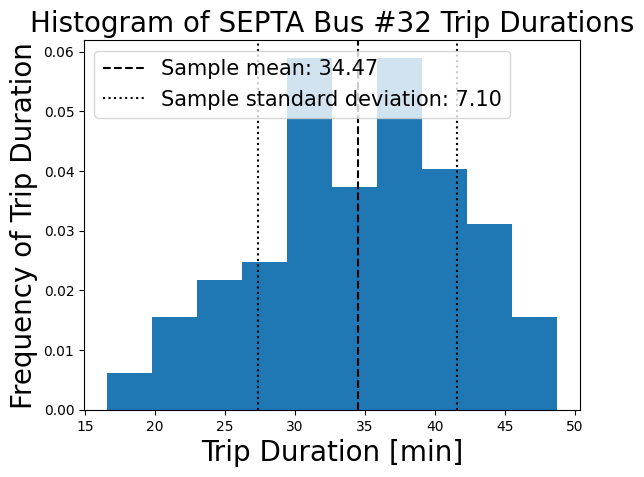

In [3]:
fig, ax = plt.subplots()
ax.hist(sample, bins=10, density=True)

ax.axvline(x=sample.mean(), c="k", ls="--", label=f"Sample mean: {sample.mean():.2f}")
ax.axvline(x=sample.mean()-sample.std(), c="k", ls=":", label=f"Sample standard deviation: {sample.std():.2f}")
ax.axvline(x=sample.mean()+sample.std(), c="k", ls=":")

ax.set_title("Histogram of SEPTA Bus #32 Trip Durations", fontsize=20)
ax.set_xlabel("Trip Duration [min]", fontsize=20)
ax.set_ylabel("Frequency of Trip Duration", fontsize=20)
ax.legend(loc="upper left", fontsize=15)
fig.show()

# Step 1. Construct the Null Hypothesis ($H_0$) and Alternative Hypothesis ($H_1$)

* The **original** trip durations come from a population distributed according to a Gaussian with mean 34 minutes and standard deviation on 2.4 minutes. $$t \sim \mathcal{N}(34, 2.4)$$

* The Null Hypothesis ($H_0$) will be that the **new** trip durations come from this same distribution.

* The Alternative Hypothesis ($H_1$) will be that the **new** trip durations come from a different population which has a smaller mean.

> $H_0$: "The sample of trip durations comes from a population with mean $\mu_0 = 34$ and standard deviation $\sigma_0=2.4$."

> $H_1$: "The sample of trip durations comes from a population with mean less than $\mu_0$."


# Step 2: Select a confidence level

* SEPTA claims the trip times are shorter, but we have a freedom to choose a threshold on this claim.

* Let us choose $\alpha = 5\%$. This is our confidence level

* We need to determine the confidence interval now. If the sample mean $\hat{t}$ falls outside of this region, we can reject the $H_0$. The range of values for which we reject $H_0$ is know as the "critical region" of the test.

* We are interested in doing a "one-tailed" test, since we only care about whether the sample mean is smaller than $\mu_0$.

* A reminder on what the p-value is from [Wikipedia](https://en.wikipedia.org/wiki/P-value):

> "The p-value is the probability of obtaining test results at least as extreme as the result actually observed, under the assumption that the null hypothesis is correct."

> "A very small p-value means that such an extreme observed outcome would be very unlikely under the null hypothesis."

Thus, when we perform the Z-test to find Z, and then we use Z to find the p-value, if the p-value is smaller than our threshold we reject H_0. If it is larger than our threshold we do not reject H_0.

# Step 3: Calculate the Z-test

In [4]:
mu0 = 34
sd0 = 2.4
n = sample.size
t_bar = sample.mean()
print(t_bar)

Z = (t_bar - mu0) / (sd0 / np.sqrt(n))
Z

34.4661616883


np.float64(1.9423403679166582)

# Step 4: Calculate the p-value of the test.

The result of the Z-test, Z, is the ["Standard Score" or "Z-Score"](https://en.wikipedia.org/wiki/Standard_score) is the number of standard deviations from $\mu_0$ that our sample mean is.

To find the p-value we can see where the Z-Score lies on the Cumulative Distribution Function (CDF; the integral of the PDF).

![CDF](https://upload.wikimedia.org/wikipedia/commons/thumb/c/ca/Normal_Distribution_CDF.svg/2560px-Normal_Distribution_CDF.svg.png)

In [5]:
left_tailed_p = stats.norm.cdf(Z)  # For checking if the new sample has a SMALLER mean
right_tailed_p = stats.norm.cdf(-Z)  # For checking if the new sample has a LARGER mean
two_tailed_p = 2 * stats.norm.cdf(- np.abs(Z))

print(f"The one-tailed p-value for the left-tailed test is: {left_tailed_p:.3f}")
print(f"The one-tailed p-value for the right-tailed test is: {right_tailed_p:.3f}")
print(f"The two-tailed p-value for the two-tailed test is: {two_tailed_p:.3f}")

The one-tailed p-value for the left-tailed test is: 0.974
The one-tailed p-value for the right-tailed test is: 0.026
The two-tailed p-value for the two-tailed test is: 0.052


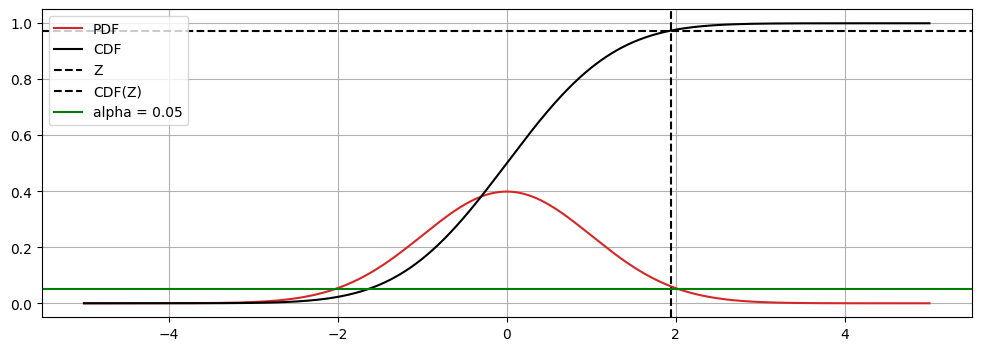

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

support = np.linspace(-5, 5, num=1000)
pdf = stats.norm.pdf(support, loc=0, scale=1)
cdf = stats.norm.cdf(support, loc=0, scale=1)

ax.plot(support, pdf, c="tab:red", label="PDF")
ax.plot(support, cdf, c="k", label="CDF")

ax.axvline(x=Z, c="k", ls="--", label="Z")
# ax.axvline(x=-Z, c="k", ls=":", label="-Z")

ax.axhline(y=left_tailed_p, c="k", ls="--", label="CDF(Z)")
# ax.axhline(y=right_tailed_p, c="k", ls=":", label="CDF(-Z)")

alpha = 0.05
ax.axhline(y=alpha, c="g", label="alpha = 0.05")

ax.legend(loc="upper left")
ax.grid()
fig.show()

# The Kolmogorov-Smirnov Test ([KS Test](https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test))

The 2-sample KS Test determines if two samples are from the same distribution. Let us contrive our own distributions and use the 2-sample KS Test on them.

# Step -1: Generate our two samples

* Step 0 will always be data exploration and visualization, so this is Step -1!

* Let's generate two samples from the same distribution (samples 1a and 1b), and two samples from different distributions (samples 2a and 2b).

In [7]:
sample_1a = stats.norm.rvs(loc=0, scale=1, size=10_000)
sample_1b = stats.norm.rvs(loc=0, scale=1, size=10_000)

sample_2a = stats.norm.rvs(loc=0, scale=1, size=10_000)
sample_2b = stats.norm.rvs(loc=0, scale=1.1, size=10_000)

# Step 0: Data Exploration and Visualization

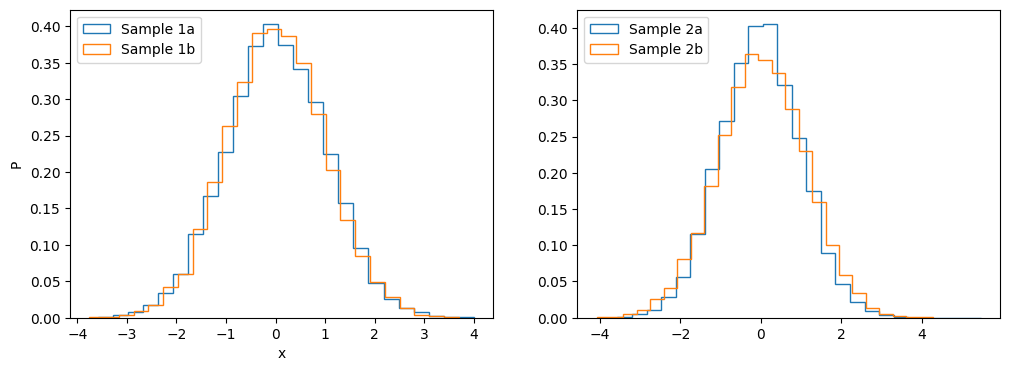

In [8]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))

axes[0].hist(sample_1a, bins=25, density=True, histtype="step", label="Sample 1a")
axes[0].hist(sample_1b, bins=25, density=True, histtype="step", label="Sample 1b")

axes[1].hist(sample_2a, bins=25, density=True, histtype="step", label="Sample 2a")
axes[1].hist(sample_2b, bins=25, density=True, histtype="step", label="Sample 2b")

axes[0].set_xlabel("x")
axes[0].set_ylabel("P")

axes[0].legend(loc="upper left")
axes[1].legend(loc="upper left")
fig.show()

# Step 1. Construct the Null Hypothesis ($H_0$) and Alternative Hypothesis ($H_1$)

The KS test has it's own $H_0$: the two samples are from the same parent distribution.

# Step 2: Select a confidence level

Our confidence level will be:

$$\alpha =\ 0.000063$$

4 sigma!

# Step 3: Calculate the KS-Test

The [ks_2samp](docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_2samp.html) from SciPy will automatically calculate the two-tailed p-value for us.

Remember the interpretation of the p-value:

> "A very small p-value means that such an extreme observed outcome would be very unlikely under the null hypothesis."

In [14]:
stats.ks_2samp(sample_1a, sample_1b)

KstestResult(statistic=np.float64(0.0129), pvalue=np.float64(0.37616617897202725), statistic_location=np.float64(0.6294355988482124), statistic_sign=np.int8(-1))

In [15]:
stats.ks_2samp(sample_2a, sample_2b)

KstestResult(statistic=np.float64(0.0364), pvalue=np.float64(3.5141343397984066e-06), statistic_location=np.float64(0.6519264001957228), statistic_sign=np.int8(1))

In [18]:
0.0000035

3.5e-06

In [19]:
alpha = 0.000064
alpha

6.4e-05